# Working without known $f^*$: Convergence analysis, anytime performance

All previous sessions used problems with a known optimum — eg. DeJong1 ($f^* = 0$), Rastrigin ($f^* = 0$). This let us compute:

$$REL = \frac{m}{q}, \quad MNE = \frac{1}{m}\sum_{i=1}^m \text{neval}_i, \quad FEO = \frac{MNE}{REL}$$

where $m$ is the number of successful runs (those reaching $f^*$) out of $q$ total.

In real-world problems this breaks down:
- **$f^*$ unknown**: parameter tuning, likelihood maximisation — the true optimum is not accessible
- **$f^*$ unachievable**: IoU = 1.0 is theoretically optimal but never actually reached
- **$f^*$ sensitive**: FEO changes dramatically with a small change in the target threshold

This session introduces three tools that work without a known $f^*$:
1. **Fixed-budget analysis** — distribution of `best_y` after $B$ evaluations
2. **Convergence curves** — best-so-far as a function of evaluations (*anytime performance*)
3. **ERT (Expected Running Time)** — generalisation of FEO to arbitrary quality targets

In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from objfun import ObjFun
from objfun_dejong1 import DeJong1
from objfun_rastrigin import Rastrigin
from heur_fsa import FastSimulatedAnnealing
from heur_go import GeneticOptimization, RandomCombination
from heur_aux import CauchyMutation, MirrorCorrection

## 1. The $f^*$ sensitivity problem

FEO is only meaningful when $f^*$ is set correctly. The same algorithm, same budget, same problem — but different $f^*$ thresholds give completely different FEO values.

In [3]:
N_DEMO = 200
MAXEVAL = 500

def run_fsa(of, seed):
    return FastSimulatedAnnealing(
        of, maxeval=MAXEVAL, T0=1.0, n0=100, alpha=2,
        mutation=CauchyMutation(r=0.1, correction=MirrorCorrection(of)),
        seed=seed
    ).search()

rows = []
for eps, label in [(1.0, 'too easy  (ε=1.0)'),
                   (0.01, 'correct   (ε=0.01)'),
                   (1e-5, 'too hard  (ε=1e-5)')]:
    of = DeJong1(n=5, eps=eps)
    results = [run_fsa(of, i) for i in range(N_DEMO)]
    rel = np.mean([r['success'] for r in results])
    successful_nevals = [r['neval'] for r in results if r['success']]
    mne = np.mean(successful_nevals) if successful_nevals else np.nan
    feo = mne / rel if rel > 0 else np.inf
    rows.append({'f* threshold': label, 'f*': eps, 'REL': round(rel, 3),
                 'MNE': round(mne, 1) if not np.isnan(mne) else '—',
                 'FEO': round(feo, 1) if np.isfinite(feo) else '∞'})

pd.DataFrame(rows).set_index('f* threshold')

,f*,REL,MNE,FEO
f* threshold,,,,
too easy (ε=1.0),1.00000,1.00,111.3,111.3
correct (ε=0.01),0.01000,0.07,421.5,6021.4
too hard (ε=1e-5),0.00001,0.00,—,∞


The algorithm's behaviour did not change — only the definition of "success" did. FEO is a function of both the algorithm *and* the threshold choice.

When $f^*$ is unknown or unreachable, we need alternatives that do not depend on a binary success criterion.

## 2. Infrastructure: logging evaluations

To analyse convergence, we need per-evaluation data — specifically the **best-so-far** trajectory. We instrument the objective function using a thin wrapper that logs every evaluation without modifying the heuristics.

In [4]:
class LoggedObjFun(ObjFun):
    """
    Thin wrapper around any ObjFun that records every evaluation.
    Compatible with all course heuristics — no changes to heuristic code needed.
    """
    def __init__(self, of: ObjFun) -> None:
        super().__init__(of.fstar, of.a.copy(), of.b.copy())
        self._of = of
        self._log = []

    def generate_point(self, rng=None):
        return self._of.generate_point(rng)

    def evaluate(self, x):
        y = self._of.evaluate(x)
        self._log.append(float(y))
        return y

    def best_so_far(self):
        """Running minimum over all logged evaluations — the convergence curve."""
        return np.minimum.accumulate(self._log) if self._log else np.array([])


def experiment_fsa_logged(of_class, of_kwargs, maxeval, num_runs, T0, n0, alpha, r, label):
    results, curves = [], []
    for i in tqdm(range(num_runs), desc=f'FSA {label}'):
        lof = LoggedObjFun(of_class(**of_kwargs))
        result = FastSimulatedAnnealing(
            lof, maxeval=maxeval, T0=T0, n0=n0, alpha=alpha,
            mutation=CauchyMutation(r=r, correction=MirrorCorrection(lof)),
            seed=i
        ).search()
        curve = lof.best_so_far()
        padded = np.full(maxeval, curve[-1])
        padded[:len(curve)] = curve
        curves.append(padded)
        result['run'] = i
        result['heur'] = label
        results.append(result)
    return (pd.DataFrame(results, columns=['heur', 'run', 'best_x', 'best_y', 'neval', 'success']),
            np.array(curves))


def experiment_go_logged(of_class, of_kwargs, maxeval, num_runs, N, M, r, label):
    results, curves = [], []
    for i in tqdm(range(num_runs), desc=f'GO {label}'):
        lof = LoggedObjFun(of_class(**of_kwargs))
        result = GeneticOptimization(
            lof, maxeval=maxeval, N=N, M=M, Tsel1=1.0, Tsel2=0.1,
            mutation=CauchyMutation(r=r, correction=MirrorCorrection(lof)),
            crossover=RandomCombination(),
            seed=i
        ).search()
        curve = lof.best_so_far()
        padded = np.full(maxeval, curve[-1])
        padded[:len(curve)] = curve
        curves.append(padded)
        result['run'] = i
        result['heur'] = label
        results.append(result)
    return (pd.DataFrame(results, columns=['heur', 'run', 'best_x', 'best_y', 'neval', 'success']),
            np.array(curves))

In [5]:
NUM_RUNS = 500
MAXEVAL  = 500
OF_CLASS  = DeJong1
OF_KWARGS = {'n': 5, 'eps': 0.01}

df_fsa, curves_fsa = experiment_fsa_logged(
    OF_CLASS, OF_KWARGS, MAXEVAL, NUM_RUNS,
    T0=1.0, n0=100, alpha=2, r=0.1, label='FSA')

df_go, curves_go = experiment_go_logged(
    OF_CLASS, OF_KWARGS, MAXEVAL, NUM_RUNS,
    N=10, M=30, r=0.05, label='GO')

all_df     = pd.concat([df_fsa, df_go], ignore_index=True)
all_curves = {'FSA': curves_fsa, 'GO': curves_go}

FSA FSA:   0%|          | 0/500 [00:00<?, ?it/s]

GO GO:   0%|          | 0/500 [00:00<?, ?it/s]

## 3. Fixed-budget analysis

Instead of asking *"how many evaluations to reach $f^*$?"*, ask: *"what quality did we reach after $B$ evaluations?"*

The primary output is the **distribution of `best_y`** at budget exhaustion — no knowledge of $f^*$ required.

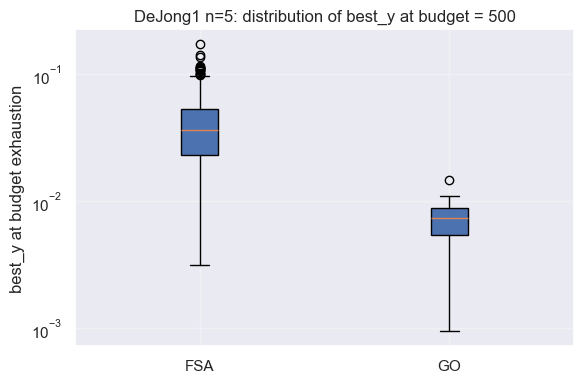

          mean       std       min       25%       50%       75%       max
heur                                                                      
FSA   0.040681  0.025108  0.003126  0.022892  0.036092  0.053373  0.173721
GO    0.006977  0.002275  0.000934  0.005401  0.007377  0.008825  0.014723


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([df_fsa['best_y'].values, df_go['best_y'].values],
           tick_labels=['FSA', 'GO'], patch_artist=True)
ax.set_ylabel('best_y at budget exhaustion')
ax.set_yscale('log')
ax.set_title(f'DeJong1 n=5: distribution of best_y at budget = {MAXEVAL}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(all_df.groupby('heur')['best_y'].describe()[['mean','std','min','25%','50%','75%','max']].round(6))

GO is clearly the stronger method here: median `best_y` ≈ 0.007 vs FSA's ≈ 0.036, and GO's distribution is much tighter (std 0.002 vs 0.025). Importantly, this conclusion is visible from the box plots alone — no knowledge of $f^*$ = 0.01 was needed. Note also that FSA's median (0.036) is above $f^*$, meaning it would be rated as "almost always failing" by FEO — yet it still finds solutions of practical quality. Fixed-budget analysis captures this nuance that FEO misses.

### Budget sensitivity

Does the ranking change if we look at a different budget? A robust method should maintain its advantage across budget levels.

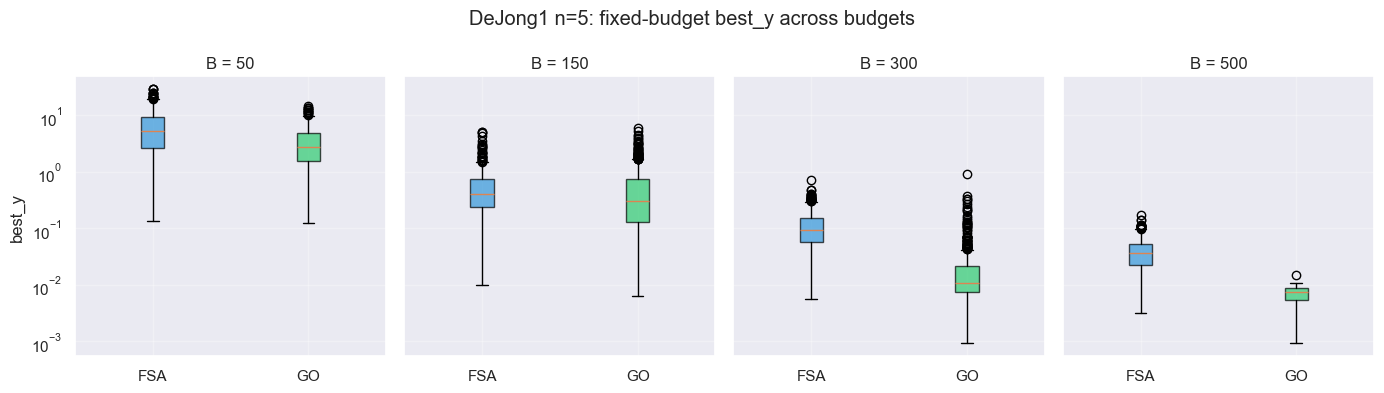

In [7]:
budgets = [50, 150, 300, 500]
fig, axes = plt.subplots(1, len(budgets), figsize=(14, 4), sharey=True)

for ax, B in zip(axes, budgets):
    data = [curves_fsa[:, B-1], curves_go[:, B-1]]
    bp = ax.boxplot(data, tick_labels=['FSA', 'GO'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'B = {B}')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    if B == budgets[0]:
        ax.set_ylabel('best_y')

fig.suptitle('DeJong1 n=5: fixed-budget best_y across budgets')
plt.tight_layout()
plt.show()

GO's advantage is already visible at B=50 and grows with budget. The ranking is stable across all four budget levels — this is the key robustness check. If the ranking flipped between B=150 and B=300, we would need to qualify our conclusions ("method A is better for small budgets, B for large"). Here it does not, so the conclusion is budget-independent.

## 4. Convergence curves — anytime performance

An **anytime algorithm** produces a valid solution at any point during its run, which improves over time. The **convergence curve** (best-so-far vs. evaluations) is the natural performance profile for anytime algorithms.

- **Fast initial drop** → good exploration, useful with small budgets
- **Sustained improvement** → efficient exploitation  
- **Early plateau** → stagnation (see Section 6)

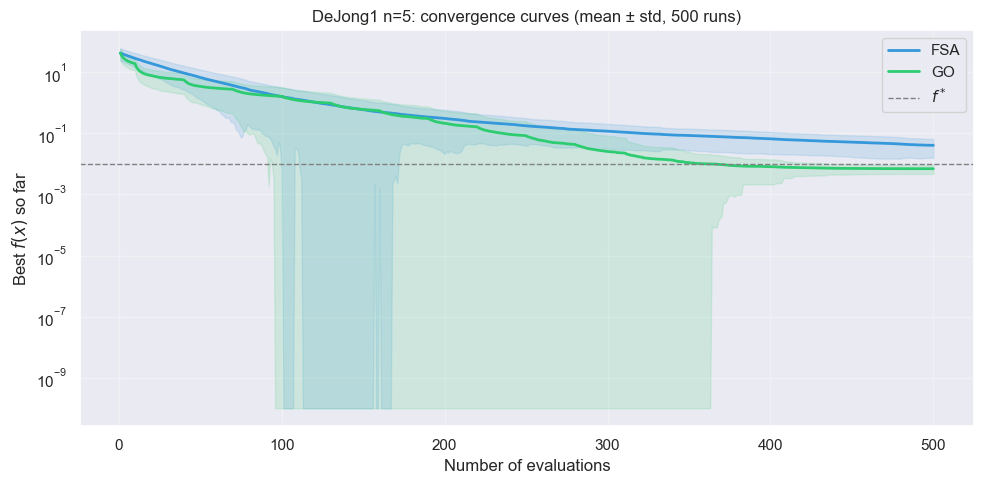

In [8]:
colors = {'FSA': '#3498db', 'GO': '#2ecc71'}
evals  = np.arange(1, MAXEVAL + 1)

fig, ax = plt.subplots(figsize=(10, 5))
for label, curves in all_curves.items():
    mean = np.mean(curves, axis=0)
    std  = np.std(curves, axis=0)
    ax.plot(evals, mean, label=label, color=colors[label], linewidth=2)
    # clip lower band to avoid negative values on log scale
    ax.fill_between(evals, np.clip(mean - std, 1e-10, None), mean + std,
                    color=colors[label], alpha=0.15)

ax.axhline(DeJong1(**OF_KWARGS).fstar, color='gray', linestyle='--', linewidth=1, label='$f^*$')
ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Best $f(x)$ so far')
ax.set_yscale('log')
ax.set_title(f'DeJong1 n=5: convergence curves (mean ± std, {NUM_RUNS} runs)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

GO converges faster and deeper. Its curve shows a characteristic **step structure** — improvements arrive in discrete jumps (one per generation, each evaluating M=30 offspring) rather than smoothly. FSA's curve is smoother but slower, staying an order of magnitude above GO's throughout the budget. The wide ±std bands early in both curves reflect high run-to-run variability (starting from different random points); they narrow as runs converge. The dashed $f^*$ line shows that GO regularly crosses it while FSA rarely does — consistent with the REL difference seen in cell 20.

### Area under the convergence curve (AUC)

A single scalar that summarises anytime performance: the integral of the convergence curve over the budget (on a log scale, to weight improvements across orders of magnitude equally).

**Lower AUC = better** — the algorithm found good solutions sooner.

In [9]:
def auc_log(curves, clip_min=1e-10):
    """Mean area under log10(convergence curve) over runs."""
    log_curves = np.log10(np.clip(curves, clip_min, None))
    return np.mean(np.trapz(log_curves, axis=1))

rows = []
for label, curves in all_curves.items():
    rows.append({
        'heur': label,
        'median best_y': np.median(curves[:, -1]),
        'AUC (log10·evals)': round(auc_log(curves), 2)
    })
pd.DataFrame(rows).set_index('heur')

,median best_y,AUC (log10·evals)
heur,,
FSA,0.036092,-306.77
GO,0.007377,-576.39


GO's AUC (≈ −576) is nearly twice as negative as FSA's (≈ −307). Since the area is computed on a log scale, this means GO found solutions roughly an order of magnitude better, on average, across the entire budget — not just at the end. AUC is particularly useful when two methods have similar final quality but one converges much earlier (something a single end-budget measurement would miss).

## 5. Fixed-target analysis — ERT

The flip side of fixed-budget: given a **quality target** $q$, how many evaluations does it take to reach it?

$$\text{ERT}(q) = \frac{\sum_{i=1}^N T_i(q)}{|\{i : T_i(q) < \infty\}|}$$

where $T_i(q)$ is the first evaluation at which run $i$ reaches quality $q$, or $B$ (budget) if it never does.

**FEO is a special case of ERT** evaluated at $q = f^*$ — but ERT extends to any target, including ones we define ourselves without knowing the true optimum.

> Note: ERT and FEO are related but not identical. FEO = MNE/REL assumes an infinite sequence of independent restarts; ERT penalises failed runs at budget $B$. They coincide when REL $\approx$ 1.

In [10]:
def compute_ert(curves, targets, maxeval):
    """
    Compute ERT for a set of convergence curves at each quality target.
    Failed runs (never reaching q) contribute maxeval to the total.
    """
    n_runs = len(curves)
    rows = []
    for q in targets:
        total_evals = 0
        n_success = 0
        for curve in curves:
            hits = np.where(np.asarray(curve) <= q)[0]
            if len(hits) > 0:
                total_evals += int(hits[0]) + 1
                n_success   += 1
            else:
                total_evals += maxeval
        ert = total_evals / n_success if n_success > 0 else np.inf
        rows.append({'target': q, 'ert': ert, 'rel': n_success / n_runs})
    return pd.DataFrame(rows)

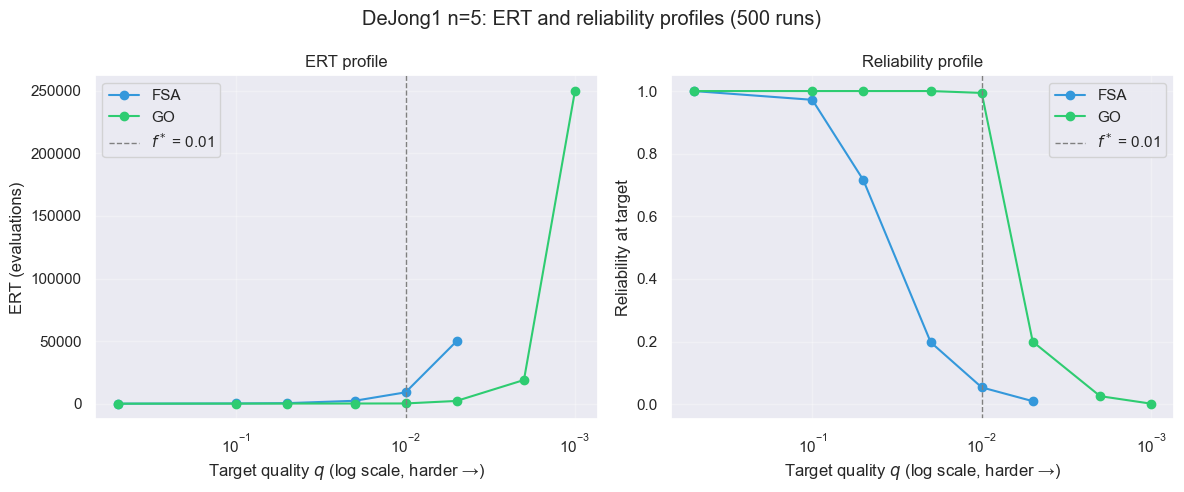

In [11]:
targets = [0.5, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
fstar   = DeJong1(**OF_KWARGS).fstar  # 0.01

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for label, curves in all_curves.items():
    ert_df = compute_ert(curves, targets, MAXEVAL)
    finite = ert_df[np.isfinite(ert_df['ert'])]
    ax1.plot(finite['target'], finite['ert'], 'o-', label=label, color=colors[label])
    ax2.plot(finite['target'], finite['rel'], 'o-', label=label, color=colors[label])

for ax in (ax1, ax2):
    ax.axvline(fstar, color='gray', linestyle='--', linewidth=1, label=f'$f^*$ = {fstar}')
    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.set_xlabel('Target quality $q$ (log scale, harder →)')
    ax.legend()
    ax.grid(True, alpha=0.3)

ax1.set_ylabel('ERT (evaluations)')
ax1.set_title('ERT profile')
ax2.set_ylabel('Reliability at target')
ax2.set_title('Reliability profile')

fig.suptitle(f'DeJong1 n=5: ERT and reliability profiles ({NUM_RUNS} runs)')
plt.tight_layout()
plt.show()

Both ERT curves rise from left (easy targets, low ERT) to right (hard targets, high ERT). GO's curve lies well below FSA's across the entire range — at $f^*$ = 0.01, GO's ERT is roughly 30× lower. The reliability profile confirms that GO reaches all tested targets almost certainly (REL ≈ 1 for $q \geq 0.01$), while FSA's reliability drops sharply for targets tighter than ≈ 0.05. The vertical dashed line marks $f^*$ — to its left are targets tighter than "success", which illustrates how ERT extends naturally beyond the binary success/failure boundary that FEO imposes.

In [12]:
# Validate: ERT at f* should be close to FEO
print('Comparison at target = f* = 0.01')
print('=' * 55)
print(f'{"Method":<6}  {"FEO":>8}  {"ERT(f*)":>8}  {"REL":>6}')
print('-' * 55)

for label, df, curves in [('FSA', df_fsa, curves_fsa), ('GO', df_go, curves_go)]:
    rel = df['success'].mean()
    mne = df.loc[df['success'], 'neval'].mean() if rel > 0 else np.nan
    feo = mne / rel if rel > 0 else np.inf
    ert_row = compute_ert(curves, [fstar], MAXEVAL).iloc[0]
    print(f'{label:<6}  {feo:>8.1f}  {ert_row["ert"]:>8.1f}  {rel:>6.4f}')

print()
print('FEO = MNE/REL  (expected cost per success, infinite-restart model)')
print('ERT = (sum of hitting times + B × failures) / successes  (fixed-budget model)')

Comparison at target = f* = 0.01
Method       FEO   ERT(f*)     REL
-------------------------------------------------------
FSA       7668.0    9173.3  0.0540
GO         306.4     307.6  0.9940

FEO = MNE/REL  (expected cost per success, infinite-restart model)
ERT = (sum of hitting times + B × failures) / successes  (fixed-budget model)


For **GO** (REL ≈ 0.994): FEO ≈ 306 ≈ ERT ≈ 308. When almost every run succeeds, both metrics converge to MNE — the penalty for failed runs is negligible. For **FSA** (REL ≈ 0.054): FEO = 7668 but ERT = 9173. They diverge because ERT penalises each failed run with the full budget B=500 (93 failed runs × 500 = large total), while FEO assumes an infinite sequence of restarts and ignores the wasted budget. **Rule of thumb:** use FEO when comparing algorithms across many runs as a normalised cost; use ERT when the experiment is fixed and the penalty for wasted runs matters.

## 6. Working without $f^*$

When $f^*$ is genuinely unknown, we have two practical strategies:

**Strategy A — Percentile targets.** Use percentiles of the empirical `best_y` distribution across all methods and runs as targets. The 90th percentile is "easy to reach", the 50th percentile is "typical performance". No knowledge of the true optimum needed.

**Strategy B — Domain threshold.** Define an *acceptable* quality level from domain knowledge (e.g., "IoU > 0.90 is good enough") and use that as the ERT target.

A key property to verify: does the **method ranking** remain stable across target choices? If it does, the conclusions are robust and don't depend on a specific threshold.

In [13]:
# Use percentiles of the combined best_y distribution as targets — no f* needed
all_best = np.concatenate([curves_fsa[:, -1], curves_go[:, -1]])
pct_labels = {90: 'easy (p90)', 75: 'moderate (p75)', 50: 'good (p50)', 25: 'excellent (p25)'}
pct_targets = {p: np.percentile(all_best, p) for p in [90, 75, 50, 25]}

print(f'True f* = {fstar}  (shown for reference only — pretend we do not know it)')
print()
print(f'{"Percentile target":<22} {"threshold":>10} {"FSA REL":>9} {"FSA ERT":>9} {"GO REL":>8} {"GO ERT":>9}')
print('-' * 72)
for p, label in pct_labels.items():
    q = pct_targets[p]
    r_fsa = compute_ert(curves_fsa, [q], MAXEVAL).iloc[0]
    r_go  = compute_ert(curves_go,  [q], MAXEVAL).iloc[0]
    fsa_ert = f'{r_fsa["ert"]:.1f}' if np.isfinite(r_fsa['ert']) else '∞'
    go_ert  = f'{r_go["ert"]:.1f}'  if np.isfinite(r_go['ert'])  else '∞'
    print(f'{label:<22} {q:>10.4f} {r_fsa["rel"]:>9.2f} {fsa_ert:>9} {r_go["rel"]:>8.2f} {go_ert:>9}')

print()
print('GO consistently requires fewer evaluations — ranking is stable across all target levels.')

True f* = 0.01  (shown for reference only — pretend we do not know it)

Percentile target       threshold   FSA REL   FSA ERT   GO REL    GO ERT
------------------------------------------------------------------------
easy (p90)                 0.0590      0.80     469.3     1.00     218.5
moderate (p75)             0.0361      0.50     873.2     1.00     238.1
good (p50)                 0.0098      0.05   10338.7     0.95     330.0
excellent (p25)            0.0072      0.02   22647.4     0.48     849.3

GO consistently requires fewer evaluations — ranking is stable across all target levels.


GO requires far fewer evaluations at every target level. At the easy target (p90 ≈ 0.059), GO reaches it in ~219 evals on average vs ~469 for FSA. At the tight target (p25 ≈ 0.007), GO needs ~849 evals while FSA's ERT exceeds 10 000 — it would need roughly 20+ independent restarts to get one success at that level. The ranking is stable and the gap grows as targets tighten. This table was produced with no knowledge of the true $f^*$: the thresholds came entirely from the observed outcome distribution.

## 7. Stagnation detection

With a large `maxeval`, runs often plateau long before the budget is exhausted. **Stagnation stopping** terminates a run when no improvement has been seen in the last $K$ evaluations ("patience").

From a convergence curve, the stagnation point is the first index $i$ such that `curve[i+K-1] == curve[i]`. The effective budget used is $i + K$.

**Important caveat:** this only works well for methods whose best-so-far curve converges *cleanly*. FSA regularly accepts worse solutions during search, so its best-so-far curve has long flat periods followed by sudden late improvements — a temporary plateau is not convergence. GO, which only keeps improvements, converges more cleanly and responds better to stagnation stopping.

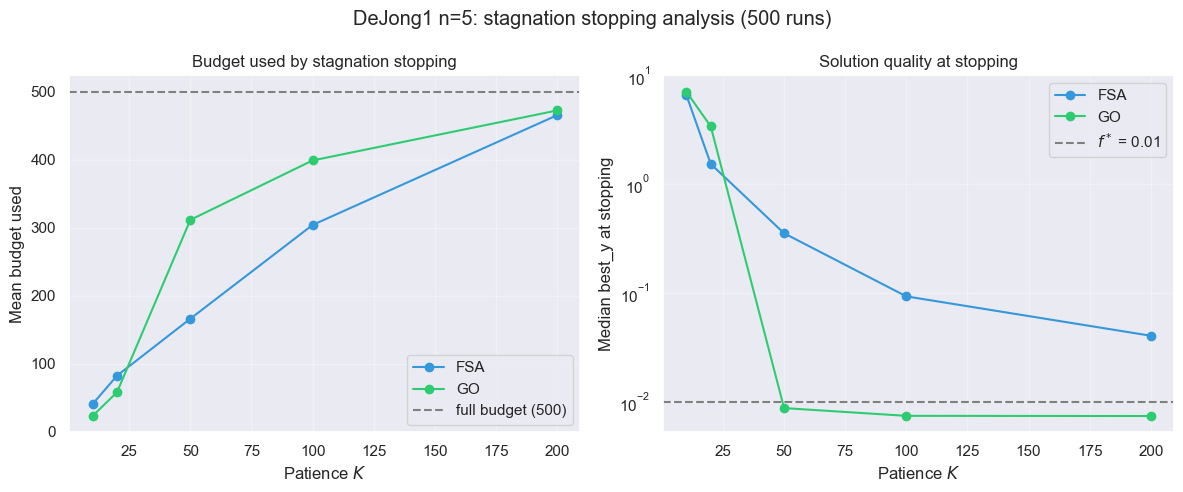

In [14]:
def stagnation_point(curve, K):
    """Return (effective_budget, quality_at_stop) for stagnation patience K."""
    for i in range(len(curve) - K + 1):
        if curve[i + K - 1] == curve[i]:  # no improvement in window
            return i + K, curve[i + K - 1]
    return len(curve), curve[-1]          # no stagnation detected


K_values = [10, 20, 50, 100, 200]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, curves in all_curves.items():
    mean_budget, median_quality = [], []
    for K in K_values:
        bkts, quals = zip(*[stagnation_point(c, K) for c in curves])
        mean_budget.append(np.mean(bkts))
        median_quality.append(np.median(quals))
    axes[0].plot(K_values, mean_budget,   'o-', label=label, color=colors[label])
    axes[1].plot(K_values, median_quality, 'o-', label=label, color=colors[label])

axes[0].axhline(MAXEVAL, color='gray', linestyle='--', label=f'full budget ({MAXEVAL})')
axes[0].set_xlabel('Patience $K$')
axes[0].set_ylabel('Mean budget used')
axes[0].set_title('Budget used by stagnation stopping')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(fstar, color='gray', linestyle='--', label=f'$f^*$ = {fstar}')
axes[1].set_xlabel('Patience $K$')
axes[1].set_ylabel('Median best_y at stopping')
axes[1].set_yscale('log')
axes[1].set_title('Solution quality at stopping')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'DeJong1 n=5: stagnation stopping analysis ({NUM_RUNS} runs)')
plt.tight_layout()
plt.show()

**Left panel (budget used):** GO shows a sharp cliff between K=20 (ca. 58 evals) and K=50 (ca. 312 evals). The explanation: GO evaluates M=30 offspring per generation — with K < 30, stagnation fires mid-generation. At K=50, at least one full generation of non-improvement is required, so stagnation detects actual convergence rather than an intra-generation pause. FSA's budget grows gradually, reflecting its continuous (non-bursty) improvement pattern.

**Right panel (quality at stopping):** GO's median quality drops to near $f^*$ from K=50 onward — stopping early costs little once a full generation passes without improvement. FSA only approaches $f^*$ at K=200 and still does not reach it, confirming that its best-so-far curve keeps improving late into the run. The take-away: for population-based methods, patience K should be at least one generation size (M) to be meaningful.

In [15]:
# Per-method sweet spot: find K that gives <10% quality loss
print('Stagnation stopping — per-method analysis')
print('=' * 70)
print(f'{"Method":<6}  {"K":>5}  {"Mean budget":>12}  {"Savings":>8}  {"Quality loss":>13}')
print('-' * 70)
for label, curves in all_curves.items():
    for K in [20, 50, 100, 200]:
        bkts, quals = zip(*[stagnation_point(c, K) for c in curves])
        mean_bkt     = np.mean(bkts)
        savings_pct  = 100 * (1 - mean_bkt / MAXEVAL)
        quality_loss = np.median(quals) / np.median(curves[:, -1]) - 1
        flag = ' ← sweet spot' if quality_loss < 0.10 and savings_pct > 5 else ''
        print(f'{label:<6}  {K:>5}  {mean_bkt:>12.1f}  {savings_pct:>7.1f}%  {quality_loss:>+12.0%}{flag}')
    print()

Stagnation stopping — per-method analysis
Method      K   Mean budget   Savings   Quality loss
----------------------------------------------------------------------
FSA        20          82.6     83.5%        +4155%
FSA        50         166.3     66.7%         +880%
FSA       100         304.1     39.2%         +158%
FSA       200         465.3      6.9%          +12%

GO         20          58.3     88.3%       +45985%
GO         50         311.6     37.7%          +18%
GO        100         398.9     20.2%           +0% ← sweet spot
GO        200         472.3      5.5%           +0% ← sweet spot



**GO:** K=100 is the practical sweet spot — 20% budget savings with 0% quality loss. K=50 saves 38% but at +18% quality loss, which may or may not be acceptable depending on the application. 

**FSA:** no sweet spot exists in this budget range. Even K=200 saves only 7% budget at a 12% quality cost — not worth the overhead of monitoring. The fundamental reason is FSA's Metropolis acceptance: it regularly steps to worse solutions, producing a best-so-far curve that looks "stalled" for long stretches before suddenly improving. 

**Practical rule:** stagnation stopping is well-suited to methods that converge cleanly (population-based, greedy). For SA-type methods, consider a fixed budget or a wall-clock limit instead.

## Summary

| Situation | Recommended tool |
|-----------|------------------|
| $f^*$ known, comparing algorithms | FEO (primary), convergence curves (secondary) |
| $f^*$ unknown, domain threshold available | ERT at threshold + convergence curves |
| $f^*$ unknown, no threshold | Fixed-budget box plots + AUC + ERT with percentile targets |
| Oracle is expensive, budget matters | Stagnation stopping — tune $K$ per method |

**Key takeaways:**
- FEO is sensitive to the threshold — a 100× change in $f^*$ can flip rankings entirely (FEO 111 → 6021 → ∞ in the demo above)
- Fixed-budget distributions and convergence curves do not require $f^*$ and give consistent rankings
- ERT generalises FEO to any quality target; ERT ≈ FEO when REL is high (GO: FEO=306, ERT=308); they diverge when REL is low (FSA: FEO=7668, ERT=9173)
- Percentile targets from the empirical outcome distribution are a principled replacement for $f^*$
- Stagnation stopping is method-dependent: GO's best-so-far converges cleanly — K=100 gives 20% budget savings with 0% quality loss; FSA's curve has long flat periods with late-breaking improvements — no good stagnation sweet spot exists in this budget range

## Assignments

1. **Different objective function.** Apply the full analysis pipeline (fixed-budget box plots, convergence curves, ERT profile) to Rastrigin $n=2$ using the same FSA and GO configurations. Does the ranking between the two methods change? How does the ERT profile shape differ from DeJong1 — and why?

2. **Add DE to the comparison.** Extend the experiment in cell 8 to include `DifferentialEvolution` (from session 07) as a third method. Plot its convergence curve alongside FSA and GO. DE evaluates $N$ candidates per generation — can you see this step structure in the curve? How does its AUC compare?

3. **Stagnation stopping for FSA.** The notebook shows that FSA has no good stagnation sweet spot with the default parameters. Hypothesis: FSA with a faster cooling schedule (larger `alpha`) converges more cleanly and makes stagnation stopping effective. Test this by varying `alpha` ∈ {2, 5, 10} and plotting the budget-vs-quality tradeoff curve for each.

4. **Analytical verification of ERT.** For the Recommender problem from session 02 (where $f^*$ is known and the landscape is simple), estimate the theoretical ERT at $q = f^*$ analytically from the geometry of the search space. Verify by simulation using `LoggedObjFun`. How close is the analytical estimate?

5. **Real-world application.** Wrap a real-world objective function in `LoggedObjFun` (e.g., your own semestral project ObjFun). Produce convergence curves and ERT profiles for FSA and GO. What budget is needed to reliably reach an acceptable quality threshold? Does stagnation stopping help?

## Further reading

**Anytime algorithms**
- Zilberstein, S. (1996). Using anytime algorithms in intelligent systems. *AI Magazine*, 17(3), 73–83. — The canonical reference on anytime performance; introduces the idea of evaluating algorithms by their quality-time profile rather than a single final result.

**ERT and benchmarking**
- Hansen, N., Auger, A., Ros, R., Mersmann, O., Tušar, T., & Brockhoff, D. (2021). COCO: A platform for comparing continuous optimizers in a black-box setting. *Optimization Methods and Software*, 36(1), 114–144. — Defines ERT as used in the COCO/bbob benchmarking framework, which is the standard for continuous black-box optimisation evaluation. The ERT formula in this notebook follows their convention.
- Auger, A., & Hansen, N. (2005). A restart CMA evolution strategy with increasing population size. *IEEE CEC 2005*. — Discusses ERT in the context of restarts; shows how ERT relates to the cost of a single run vs. multiple restarts.

**Performance profiles**
- Dolan, E. D., & Moré, J. J. (2002). Benchmarking optimization software with performance profiles. *Mathematical Programming*, 91(2), 201–213. — Introduces performance profiles as a method for comparing optimisers across a suite of problems without a single scalar metric. A natural complement to the ERT profile approach shown here.

**Fixed-budget analysis**
- Jansen, T., & Zarges, C. (2014). Performance analysis of randomised search heuristics operating with a fixed budget. *Theoretical Computer Science*, 545, 39–58. — Formal treatment of fixed-budget analysis as an alternative to fixed-target (FEO/ERT) analysis; discusses when each perspective is more appropriate.